<a href="https://colab.research.google.com/github/D2501R2003/From-Data-to-Decisions-Deep-Learning-Frameworks-for-Business-Case-Analysis/blob/main/ICE_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set()
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestClassifier


In [2]:
df = pd.read_csv("/content/engine_failure_dataset.csv")

# 3. If a column (e.g., 'json_column') contains JSON strings, parse it:
# df['json_column'] = df['json_column'].apply(json.loads)

display(df.head())

,Temperature (°C),RPM,Fuel_Efficiency,Vibration_X,Vibration_Y,Vibration_Z,Torque,Power_Output (kW),Fault_Condition,Operational_Mode
0,60.308585,3426.827588,20.445472,0.874657,0.005686,0.529798,107.877658,23.367684,2,Idle
1,112.705055,2949.758424,23.083947,0.696461,0.391779,0.124336,60.351655,57.941022,3,Cruising
2,108.670976,1817.971040,20.555326,0.495276,0.189714,0.886417,110.986564,47.732998,2,Cruising
3,107.114691,2730.660539,23.226431,0.986206,0.983202,0.468114,77.416793,44.112039,2,Cruising
4,118.075814,1854.488677,21.148226,0.710810,0.101139,0.481034,100.475881,80.681972,2,Cruising


In [3]:
sorted(df.columns.unique())

['Fault_Condition',
 'Fuel_Efficiency',
 'Operational_Mode',
 'Power_Output (kW)',
 'RPM',
 'Temperature (°C)',
 'Torque',
 'Vibration_X',
 'Vibration_Y',
 'Vibration_Z']

In [4]:
sorted(df['Operational_Mode'].unique())

['Cruising', 'Heavy Load', 'Idle']

In [5]:
a = df['Operational_Mode'].map({'Cruising':0, 'Heavy Load':1, 'Idle':2})
df['Operational_Mode'] = a

df.head(5)


,Temperature (°C),RPM,Fuel_Efficiency,Vibration_X,Vibration_Y,Vibration_Z,Torque,Power_Output (kW),Fault_Condition,Operational_Mode
0,60.308585,3426.827588,20.445472,0.874657,0.005686,0.529798,107.877658,23.367684,2,2
1,112.705055,2949.758424,23.083947,0.696461,0.391779,0.124336,60.351655,57.941022,3,0
2,108.670976,1817.971040,20.555326,0.495276,0.189714,0.886417,110.986564,47.732998,2,0
3,107.114691,2730.660539,23.226431,0.986206,0.983202,0.468114,77.416793,44.112039,2,0
4,118.075814,1854.488677,21.148226,0.710810,0.101139,0.481034,100.475881,80.681972,2,0


In [6]:
for column in df.columns:
  print(f"Column: {column}")
  print(f"Min: {df[column].min()}")
  print(f"Max: {df[column].max()}")


Column: Temperature (°C)
Min: 60.01311842
Max: 119.9821914
Column: RPM
Min: 1000.737383
Max: 3996.039482
Column: Fuel_Efficiency
Min: 15.04572646
Max: 29.99891198
Column: Vibration_X
Min: 0.000169645
Max: 0.999893426
Column: Vibration_Y
Min: 0.000740537
Max: 0.999531039
Column: Vibration_Z
Min: 0.001085553
Max: 0.999384001
Column: Torque
Min: 50.05914394
Max: 199.9094023
Column: Power_Output (kW)
Min: 20.1489097
Max: 99.93295607
Column: Fault_Condition
Min: 0
Max: 3
Column: Operational_Mode
Min: 0
Max: 2


In [7]:
sorted(df['Operational_Mode'].unique())

[np.int64(0), np.int64(1), np.int64(2)]

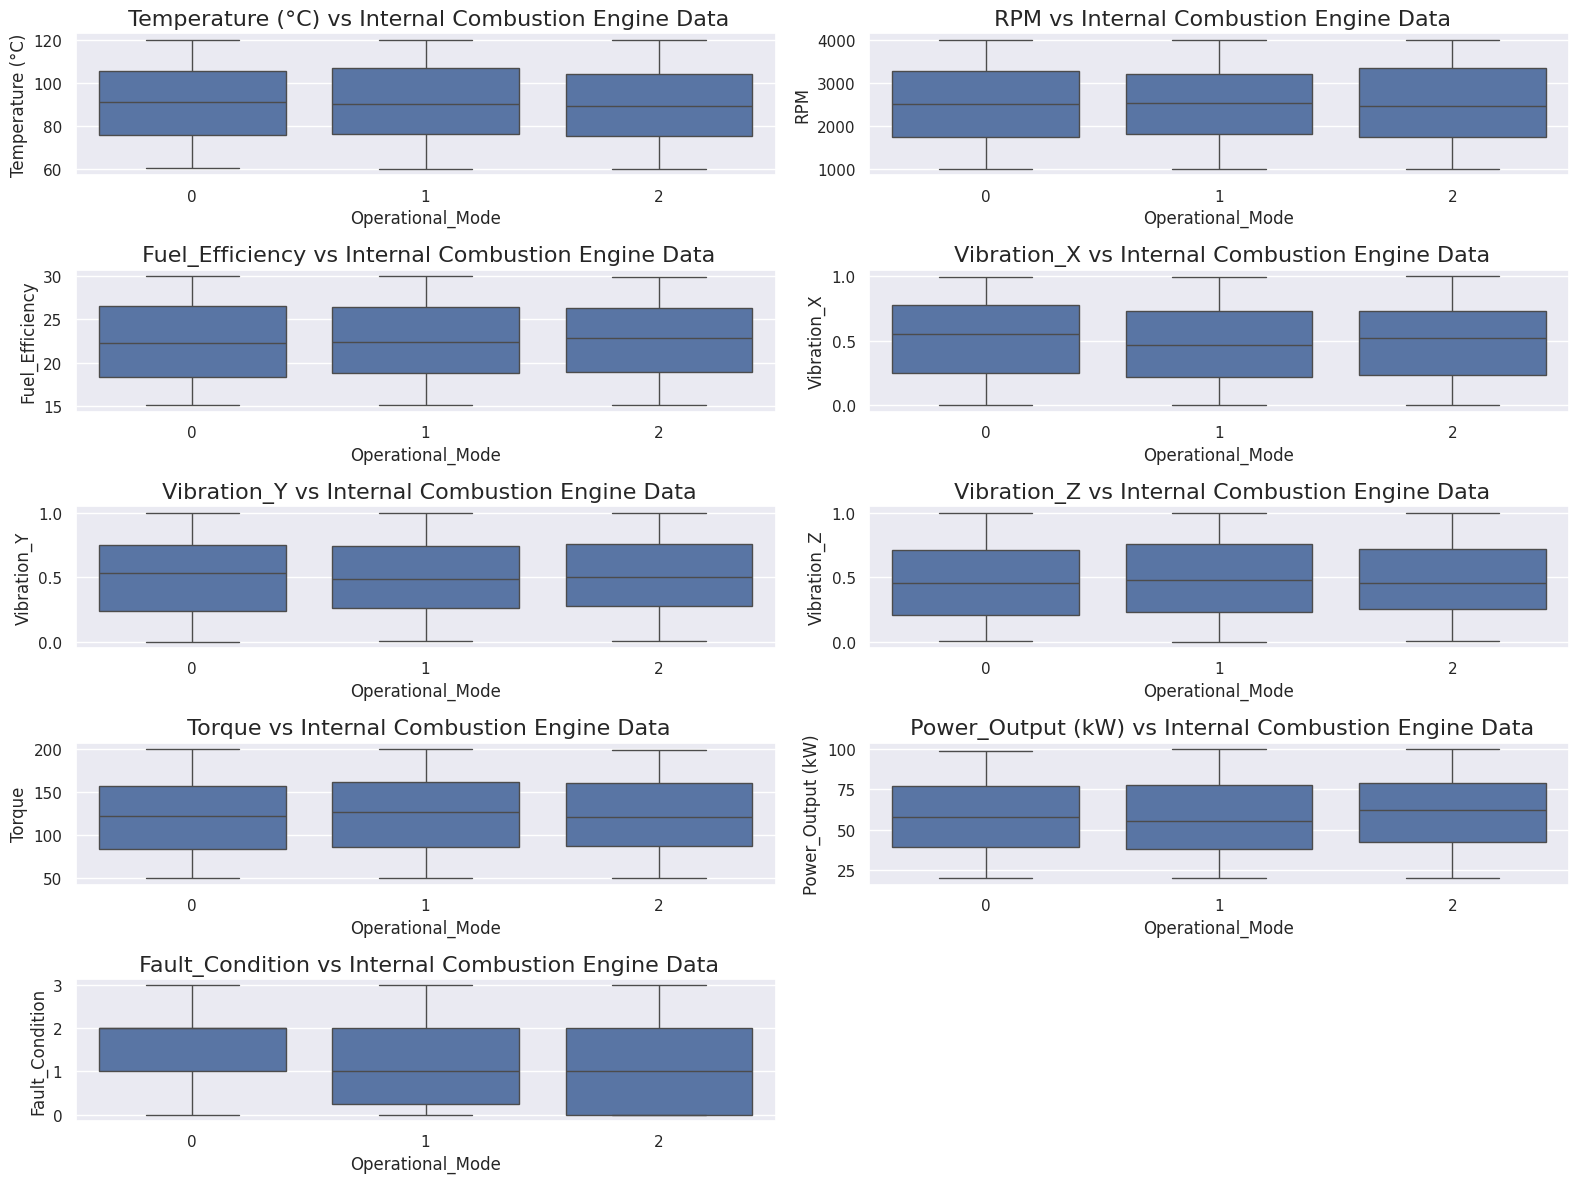

In [8]:
plt.figure(figsize=(16,12))
for idx,col in enumerate(df.columns[:-1], 1):
    plt.subplot(5,2,idx)
    sns.boxplot(x = 'Operational_Mode', y = col, data = df)
    plt.title(f' {col} vs Internal Combustion Engine Data', fontsize = 16)
plt.tight_layout()
plt.show()

In [9]:
data = df.drop(['Operational_Mode'], axis =1)
data.head(5)

,Temperature (°C),RPM,Fuel_Efficiency,Vibration_X,Vibration_Y,Vibration_Z,Torque,Power_Output (kW),Fault_Condition
0,60.308585,3426.827588,20.445472,0.874657,0.005686,0.529798,107.877658,23.367684,2
1,112.705055,2949.758424,23.083947,0.696461,0.391779,0.124336,60.351655,57.941022,3
2,108.670976,1817.971040,20.555326,0.495276,0.189714,0.886417,110.986564,47.732998,2
3,107.114691,2730.660539,23.226431,0.986206,0.983202,0.468114,77.416793,44.112039,2
4,118.075814,1854.488677,21.148226,0.710810,0.101139,0.481034,100.475881,80.681972,2


In [10]:
x = data
y = df['Operational_Mode']

In [11]:
scaler = StandardScaler()

In [12]:
scaler.fit(x)

StandardScaler()

In [13]:
x_scaled = scaler.transform(x)

In [14]:
x_scaled

array([[-1.75083770e+00,  1.05465971e+00, -4.62546481e-01, ...,
        -3.66097528e-01, -1.57671383e+00,  4.83816312e-01],
       [ 1.28726377e+00,  5.04476588e-01,  1.34297803e-01, ...,
        -1.47455773e+00, -4.17601307e-02,  1.38814587e+00],
       [ 1.05335598e+00, -8.00764600e-01, -4.37696559e-01, ...,
        -2.93587783e-01, -4.94966116e-01,  4.83816312e-01],
       ...,
       [ 1.65613501e+00, -4.45757425e-02, -1.09322972e+00, ...,
         9.46091693e-01, -1.28195822e-01,  1.38814587e+00],
       [ 6.71639848e-03, -2.47463145e-01, -1.13338666e+00, ...,
        -1.04690587e+00, -8.94715910e-01, -4.20513243e-01],
       [ 1.53079771e-01, -1.16823012e-03, -1.10686069e+00, ...,
         1.28273009e+00,  1.10492650e+00, -1.32484280e+00]])

In [15]:
train_test_split(x_scaled, y)

[array([[-0.84509771,  1.21762012,  1.13625351, ..., -0.34705204,
          1.02161381, -1.3248428 ],
        [ 1.05737787,  1.06495345,  0.27406154, ...,  1.26622329,
          1.67679663, -1.3248428 ],
        [-0.93794912,  0.67948642,  1.45673744, ...,  0.62956409,
         -1.28615536, -1.3248428 ],
        ...,
        [-1.40221676, -0.75648832,  0.30365966, ..., -0.70147879,
         -0.06385456, -0.42051324],
        [ 0.56792981,  1.27960658, -0.39452719, ...,  1.6771117 ,
         -0.98065418, -0.42051324],
        [ 1.13790794, -0.68506119,  0.98080967, ...,  0.30212849,
          1.28734769,  0.48381631]]),
 array([[ 0.34255321, -0.59641717, -0.94228788, ..., -0.2744001 ,
         -1.10320337, -0.42051324],
        [ 1.01722136,  1.09719621,  0.18503572, ...,  1.58077012,
          1.72889514, -1.3248428 ],
        [ 0.70341344,  0.9354351 , -0.42423032, ...,  1.63859152,
         -1.07388004, -0.42051324],
        ...,
        [ 0.62447471,  1.3612826 , -1.26461158, ..., -

In [16]:
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, train_size=0.8, random_state=365)
#

In [17]:
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(800, 9) (200, 9) (800,) (200,)


In [18]:
reg = RandomForestClassifier()

In [19]:
reg.fit(x_train, y_train)

RandomForestClassifier()

In [20]:
reg.score(x_train, y_train)

1.0

In [21]:
model_outputs = reg.predict(x_train)

In [22]:
model_outputs == y_train

,Operational_Mode
908,True
591,True
836,True
145,True
606,True
...,...
428,True
859,True
801,True
692,True


In [23]:
np.sum((model_outputs == y_train)) / model_outputs.shape[0]

np.float64(1.0)

In [24]:
reg.score(x_test, y_test)

0.32